In [2]:
# Librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Cargamos el archivo usando la tercera fila como encabezado

Leads = pd.read_csv("Analisis GAC Full7agosto 2026(Leads Reales).csv",header=2)

In [4]:
Leads.head()

,Año,Mes,Total,Ilocalizable,No Contesta,D. Incorrectos,Duplicados,Efectivos,Abiertos,Ventas,Conversion,Efectividad de Leads,Unnamed: 12,Unnamed: 13
0,2024.0,Enero,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Febrero,543,108,33,0,1,389,1,12,3.1%,72%,NaN,NaN
2,NaN,Marzo,178,37,13,0,0,128,1,7,5.5%,72%,NaN,NaN
3,NaN,Abril,416,79,46,3,0,288,1,8,2.8%,69%,NaN,NaN
4,NaN,Mayo,422,33,100,17,0,274,5,13,4.7%,65%,NaN,NaN


In [5]:
# Eliminamos espacios sobrantes de los nombres de las columnas

Leads.columns = Leads.columns.str.strip()


# Eliminamos las columnas llamadas unnamed

Leads = Leads.loc[:, ~Leads.columns.str.contains("Unnamed")]


# Mostramos los nombres de las columnas

Leads.columns

Index(['Año', 'Mes', 'Total', 'Ilocalizable', 'No Contesta', 'D. Incorrectos',
       'Duplicados', 'Efectivos', 'Abiertos', 'Ventas', 'Conversion',
       'Efectividad de Leads'],
      dtype='str')

In [6]:
# Eliminamos los espacios sobrantes de la columna Mes

Leads["Mes"] = Leads["Mes"].astype(str).str.strip()


# Convertimos Año a numérico y completamos los años faltantes

Leads["Año"] = pd.to_numeric(Leads["Año"],errors="coerce").ffill()

In [7]:
# Lista con meses válidos

meses = ["Enero", "Febrero", "Marzo", "Abril","Mayo", "Junio", "Julio", "Agosto", "Septiembre", "Octubre", "Noviembre", "Diciembre"]


# Filtramos solamente los registros mensuales

Leads = Leads[Leads["Mes"].isin(meses)]

In [8]:
# Variables numéricas que vamos a categorizar

variables = ["Total", "Efectivos"]

In [9]:
# Convertimos las variables seleccionadas a valores numéricos

for columna in variables:
    Leads[columna] = Leads[columna].astype(str)
    Leads[columna] = Leads[columna].str.replace(",", "")
    Leads[columna] = pd.to_numeric(Leads[columna],errors="coerce")

In [10]:
# Eliminamos los registros que tengan valores nulos

Leads = Leads.dropna(subset=variables)


# Reiniciamos el índice

Leads = Leads.reset_index(drop=True)

In [11]:
# Dimensiones finales de la base

print("Dimensiones:", Leads.shape)


# Valores nulos

Leads[variables].isnull().sum()

Dimensiones: (28, 12)


Total        0
Efectivos    0
dtype: int64

In [12]:
# Número de observaciones

n = len(Leads)

print("Número de observaciones:", n)

Número de observaciones: 28


In [13]:
# Regla de Sturges

ni = 1 + 3.32 * np.log10(n)

print("Número de intervalos sin redondear:", ni)

Número de intervalos sin redondear: 5.8045646640561674


In [14]:
# Redondeamos el resultado de Sturges

numero_intervalos = round(ni)

print("Número de intervalos:", numero_intervalos)

Número de intervalos: 6


In [15]:
# Variable 1: Total

# Límites

Max_Total = Leads["Total"].max()
Min_Total = Leads["Total"].min()

Limites_Total = [Min_Total, Max_Total]

print("Límites de Total:", Limites_Total)

Límites de Total: [np.float64(178.0), np.float64(1973.0)]


In [16]:
# Rango de Total

R_Total = Max_Total - Min_Total

print("Rango de Total:", R_Total)

Rango de Total: 1795.0


In [17]:
# Ancho o amplitud de cada intervalo

i_Total = R_Total / numero_intervalos

print("Amplitud de Total:", i_Total)

Amplitud de Total: 299.1666666666667


In [18]:
# Intervalos para Total

intervalos_Total = np.linspace(177, 1974, 7)

intervalos_Total

array([ 177. ,  476.5,  776. , 1075.5, 1375. , 1674.5, 1974. ])

In [19]:
# Nombres de las categorías de Total

categorias_Total = ["177-477", "477-776",
                    "776-1076","1076-1375",
                    "1375-1675","1675-1974"]

In [20]:
# Nueva columna con las categorías de Total

Leads["Categoria Total"] = pd.cut(x=Leads["Total"], bins=intervalos_Total, labels=categorias_Total, include_lowest=True)


# Valores originales y sus categorías

Leads[["Total", "Categoria Total"]]

,Total,Categoria Total
0,543.0,477-776
1,178.0,177-477
2,416.0,177-477
3,422.0,177-477
4,967.0,776-1076
5,954.0,776-1076
6,1409.0,1375-1675
7,1315.0,1076-1375
8,1973.0,1675-1974
9,1562.0,1375-1675


In [21]:
# Frecuencia de cada categoría

Tabla_Total = Leads["Categoria Total"].value_counts(sort=False).reset_index()

Tabla_Total

,Categoria Total,count
0,177-477,3
1,477-776,2
2,776-1076,6
3,1076-1375,9
4,1375-1675,6
5,1675-1974,2


In [22]:
# Categorías con frecuencia mayor a cero

Filtro_Total = Tabla_Total[Tabla_Total["count"] > 0]

Filtro_Total

,Categoria Total,count
0,177-477,3
1,477-776,2
2,776-1076,6
3,1076-1375,9
4,1375-1675,6
5,1675-1974,2


In [23]:
# Ajustamos el índice 

Filtro_Total_index = Filtro_Total.set_index("Categoria Total")

Filtro_Total_index

,count
Categoria Total,
177-477,3
477-776,2
776-1076,6
1076-1375,9
1375-1675,6
1675-1974,2


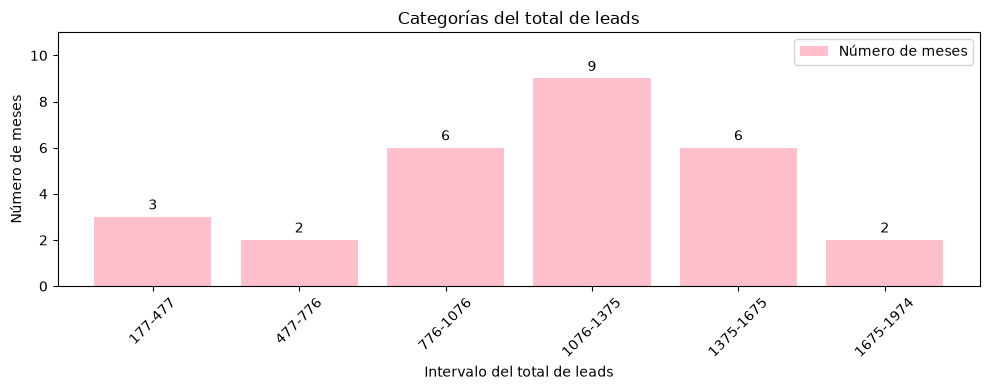

In [54]:
# Gráfica de barras 1: Total

ax = Filtro_Total_index.plot(kind="bar", width=0.8,figsize=(10, 4),color="pink",rot=45)

ax.bar_label(ax.containers[0], padding=3)

plt.ylim(0, 11)

plt.title("Categorías del total de leads")
plt.xlabel("Intervalo del total de leads")
plt.ylabel("Número de meses")
plt.legend(["Número de meses"])
plt.tight_layout()
plt.show()

In [31]:
# Variable 2: Efectivos

# Límites 

Max_Efectivos = Leads["Efectivos"].max()
Min_Efectivos = Leads["Efectivos"].min()

Limites_Efectivos = [Min_Efectivos, Max_Efectivos]

print("Límites de Efectivos:", Limites_Efectivos)

Límites de Efectivos: [np.float64(128.0), np.float64(1040.0)]


In [32]:
# Rango de Efectivos

R_Efectivos = Max_Efectivos - Min_Efectivos

print("Rango de Efectivos:", R_Efectivos)

Rango de Efectivos: 912.0


In [33]:
# Ancho o amplitud de cada intervalo

i_Efectivos = R_Efectivos / numero_intervalos

print("Amplitud de Efectivos:", i_Efectivos)

Amplitud de Efectivos: 152.0


In [34]:
# Intervalos para Efectivos

intervalos_Efectivos = np.linspace(127, 1041, 7)

intervalos_Efectivos

array([ 127.        ,  279.33333333,  431.66666667,  584.        ,
        736.33333333,  888.66666667, 1041.        ])

In [35]:
# Categorías de Efectivos

categorias_Efectivos = ["127-279","279-432",
                        "432-584","584-736",
                        "736-889", "889-1041"]

In [36]:
# Nueva columna con las categorías de Efectivos

Leads["Categoria Efectivos"] = pd.cut(x=Leads["Efectivos"],bins=intervalos_Efectivos,labels=categorias_Efectivos,include_lowest=True)


# Valores originales y sus categorías

Leads[["Efectivos", "Categoria Efectivos"]]

,Efectivos,Categoria Efectivos
0,389.0,279-432
1,128.0,127-279
2,288.0,279-432
3,274.0,127-279
4,620.0,584-736
5,570.0,432-584
6,546.0,432-584
7,530.0,432-584
8,822.0,736-889
9,1040.0,889-1041


In [37]:
# Frecuencia de cada categoría

Tabla_Efectivos = Leads["Categoria Efectivos"].value_counts(sort=False).reset_index()

Tabla_Efectivos

,Categoria Efectivos,count
0,127-279,2
1,279-432,2
2,432-584,5
3,584-736,12
4,736-889,3
5,889-1041,4


In [38]:
# Categorías con frecuencia mayor a cero

Filtro_Efectivos = Tabla_Efectivos[Tabla_Efectivos["count"] > 0]

Filtro_Efectivos

,Categoria Efectivos,count
0,127-279,2
1,279-432,2
2,432-584,5
3,584-736,12
4,736-889,3
5,889-1041,4


In [39]:
# Ajustamos el índice 

Filtro_Efectivos_index = Filtro_Efectivos.set_index("Categoria Efectivos")

Filtro_Efectivos_index

,count
Categoria Efectivos,
127-279,2
279-432,2
432-584,5
584-736,12
736-889,3
889-1041,4


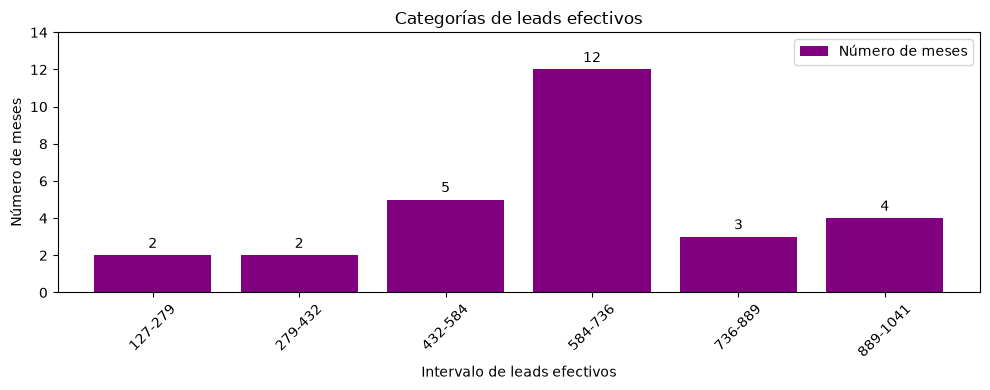

In [95]:
# Gráfica de barras 2: Efectivos

ax = Filtro_Efectivos_index.plot(kind="bar", width=0.8, figsize=(10, 4), color="purple",rot=45)

ax.bar_label(ax.containers[0], padding=3)

plt.ylim(0, Filtro_Efectivos_index["count"].max() + 2)

plt.title("Categorías de leads efectivos")
plt.xlabel("Intervalo de leads efectivos")
plt.ylabel("Número de meses")
plt.legend(["Número de meses"])
plt.tight_layout()
plt.show()

In [43]:
# Variables numéricas nuevas que vamos a categorizar

variables_nuevas = ["Ilocalizable", "No Contesta", "D. Incorrectos", "Duplicados","Abiertos"]


# Convertimos a valores numéricos

for columna in variables_nuevas:
    Leads[columna] = Leads[columna].astype(str)
    Leads[columna] = Leads[columna].str.replace(",", "")
    Leads[columna] = pd.to_numeric(Leads[columna],errors="coerce")

In [44]:
# Variable 3: Ilocalizable

# Límites, rango y amplitud 

Max_Ilocalizable = Leads["Ilocalizable"].max()
Min_Ilocalizable = Leads["Ilocalizable"].min()

R_Ilocalizable = Max_Ilocalizable - Min_Ilocalizable
i_Ilocalizable = R_Ilocalizable / numero_intervalos

print("Límites:", [Min_Ilocalizable, Max_Ilocalizable])
print("Rango:", R_Ilocalizable)
print("Amplitud:", i_Ilocalizable)

Límites: [np.int64(5), np.int64(514)]
Rango: 509
Amplitud: 84.83333333333333


In [45]:
# Intervalos para Ilocalizable

intervalos_Ilocalizable = np.linspace(4, 515, 7)

intervalos_Ilocalizable

array([  4.        ,  89.16666667, 174.33333333, 259.5       ,
       344.66666667, 429.83333333, 515.        ])

In [46]:
# Nombres de las categorías

categorias_Ilocalizable = ["4-89","89-174",
                           "174-260","260-345",
                           "345-430","430-515"]

In [47]:
# Categorizamos la variable Ilocalizable

Leads["Categoria Ilocalizable"] = pd.cut(x=Leads["Ilocalizable"],bins=intervalos_Ilocalizable,labels=categorias_Ilocalizable,include_lowest=True)

Leads[["Ilocalizable", "Categoria Ilocalizable"]]

,Ilocalizable,Categoria Ilocalizable
0,108,89-174
1,37,4-89
2,79,4-89
3,33,4-89
4,140,89-174
5,112,89-174
6,504,430-515
7,431,430-515
8,514,430-515
9,153,89-174


In [48]:
# Tabla de frecuencias

Tabla_Ilocalizable = Leads["Categoria Ilocalizable"].value_counts(sort=False).reset_index()

Tabla_Ilocalizable

,Categoria Ilocalizable,count
0,4-89,13
1,89-174,9
2,174-260,2
3,260-345,0
4,345-430,1
5,430-515,3


In [49]:
# Categorías con frecuencia mayor a cero

Filtro_Ilocalizable = Tabla_Ilocalizable[Tabla_Ilocalizable["count"] > 0]

Filtro_Ilocalizable

,Categoria Ilocalizable,count
0,4-89,13
1,89-174,9
2,174-260,2
4,345-430,1
5,430-515,3


In [50]:
# Ajustamos el índice

Filtro_Ilocalizable_index = Filtro_Ilocalizable.set_index("Categoria Ilocalizable")

Filtro_Ilocalizable_index

,count
Categoria Ilocalizable,
4-89,13
89-174,9
174-260,2
345-430,1
430-515,3


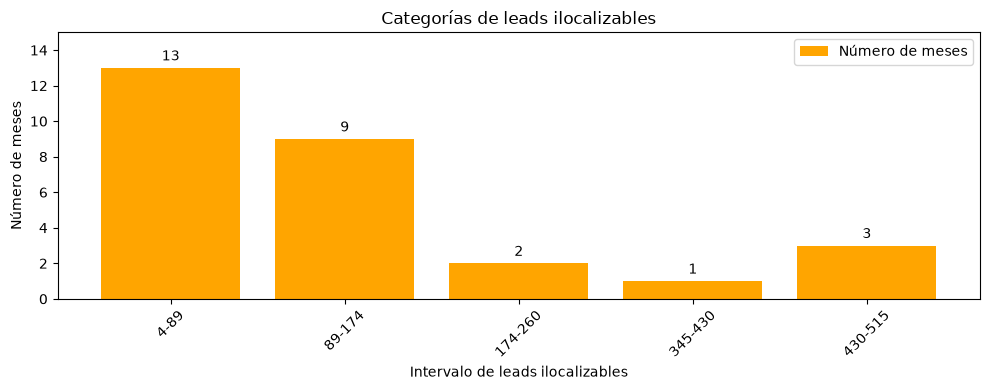

In [96]:
# Gráfica de barras 3: Ilocalizable

ax = Filtro_Ilocalizable_index.plot(kind="bar",width=0.8,figsize=(10, 4),color="orange",rot=45)

ax.bar_label(ax.containers[0], padding=3)

plt.ylim(0, Filtro_Ilocalizable_index["count"].max() + 2)

plt.title("Categorías de leads ilocalizables")
plt.xlabel("Intervalo de leads ilocalizables")
plt.ylabel("Número de meses")
plt.legend(["Número de meses"])
plt.tight_layout()
plt.show()

In [61]:
# Variable 4: No Contesta

# Límites, rango y amplitud de No Contesta

Max_NoContesta = Leads["No Contesta"].max()
Min_NoContesta = Leads["No Contesta"].min()

R_NoContesta = Max_NoContesta - Min_NoContesta
i_NoContesta = R_NoContesta / numero_intervalos

print("Límites:", [Min_NoContesta, Max_NoContesta])
print("Rango:", R_NoContesta)
print("Amplitud:", i_NoContesta)

Límites: [np.int64(13), np.int64(606)]
Rango: 593
Amplitud: 98.83333333333333


In [62]:
# Intervalos para No Contesta

intervalos_NoContesta = np.linspace(12, 607, 7)

intervalos_NoContesta

array([ 12.        , 111.16666667, 210.33333333, 309.5       ,
       408.66666667, 507.83333333, 607.        ])

In [63]:
# Nombres de las categorías

categorias_NoContesta = ["12-111","111-210",
                         "210-310","310-409",
                         "409-508","508-607"]

In [64]:
# Categorizamos la variable No Contesta

Leads["Categoria No Contesta"] = pd.cut(x=Leads["No Contesta"],bins=intervalos_NoContesta,labels=categorias_NoContesta,include_lowest=True)

Leads[["No Contesta", "Categoria No Contesta"]]

,No Contesta,Categoria No Contesta
0,33,12-111
1,13,12-111
2,46,12-111
3,100,12-111
4,173,111-210
5,251,210-310
6,324,310-409
7,314,310-409
8,606,508-607
9,321,310-409


In [65]:
# Tabla de frecuencias

Tabla_NoContesta = Leads["Categoria No Contesta"].value_counts(sort=False).reset_index()

Tabla_NoContesta

,Categoria No Contesta,count
0,12-111,9
1,111-210,8
2,210-310,4
3,310-409,4
4,409-508,1
5,508-607,2


In [66]:
# Categorías con frecuencia mayor a cero

Filtro_NoContesta = Tabla_NoContesta[Tabla_NoContesta["count"] > 0]

Filtro_NoContesta

,Categoria No Contesta,count
0,12-111,9
1,111-210,8
2,210-310,4
3,310-409,4
4,409-508,1
5,508-607,2


In [67]:
# Ajustamos el índice

Filtro_NoContesta_index = Filtro_NoContesta.set_index("Categoria No Contesta")

Filtro_NoContesta_index

,count
Categoria No Contesta,
12-111,9
111-210,8
210-310,4
310-409,4
409-508,1
508-607,2


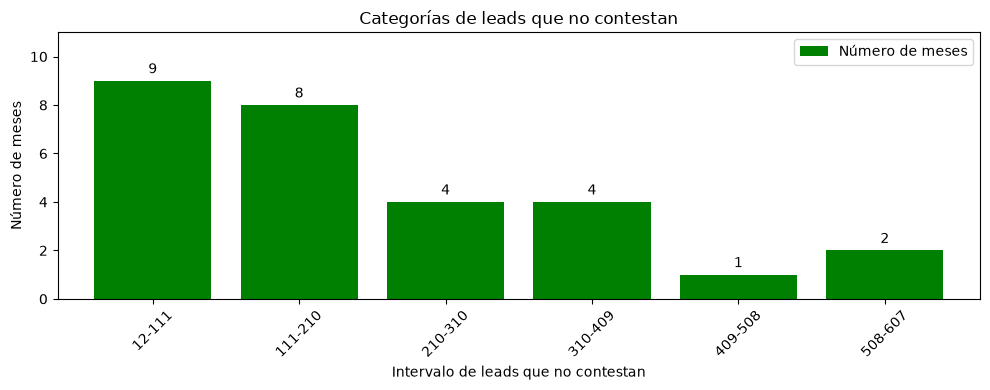

In [97]:
# Gráfica de barras 4: No Contesta

ax = Filtro_NoContesta_index.plot(kind="bar",width=0.8,figsize=(10, 4),color="green",rot=45)

ax.bar_label(ax.containers[0], padding=3)

plt.ylim(0, Filtro_NoContesta_index["count"].max() + 2)

plt.title("Categorías de leads que no contestan")
plt.xlabel("Intervalo de leads que no contestan")
plt.ylabel("Número de meses")
plt.legend(["Número de meses"])
plt.tight_layout()
plt.show()

In [69]:
# Variable 5: D. Incorrectos

# Límites, rango y amplitud de D. Incorrectos

Max_Incorrectos = Leads["D. Incorrectos"].max()
Min_Incorrectos = Leads["D. Incorrectos"].min()

R_Incorrectos = Max_Incorrectos - Min_Incorrectos
i_Incorrectos = R_Incorrectos / numero_intervalos

print("Límites:", [Min_Incorrectos, Max_Incorrectos])
print("Rango:", R_Incorrectos)
print("Amplitud:", i_Incorrectos)

Límites: [np.int64(0), np.int64(62)]
Rango: 62
Amplitud: 10.333333333333334


In [70]:
# Intervalos para D. Incorrectos

intervalos_Incorrectos = np.linspace(-1, 63, 7)

intervalos_Incorrectos

array([-1.        ,  9.66666667, 20.33333333, 31.        , 41.66666667,
       52.33333333, 63.        ])

In [71]:
# Nombres de las categorías

categorias_Incorrectos = ["-1-10","10-20",
                          "20-31","31-42",
                          "42-52","52-63"]

In [72]:
# Categorizamos la variable D. Incorrectos

Leads["Categoria D. Incorrectos"] = pd.cut(x=Leads["D. Incorrectos"],bins=intervalos_Incorrectos,labels=categorias_Incorrectos,include_lowest=True)

Leads[["D. Incorrectos", "Categoria D. Incorrectos"]]

,D. Incorrectos,Categoria D. Incorrectos
0,0,-1-10
1,0,-1-10
2,3,-1-10
3,17,10-20
4,31,20-31
5,12,10-20
6,17,10-20
7,14,10-20
8,18,10-20
9,44,42-52


In [73]:
# Tabla de frecuencias

Tabla_Incorrectos = Leads["Categoria D. Incorrectos"].value_counts(sort=False).reset_index()

Tabla_Incorrectos

,Categoria D. Incorrectos,count
0,-1-10,13
1,10-20,6
2,20-31,2
3,31-42,2
4,42-52,3
5,52-63,2


In [74]:
# Categorías con frecuencia mayor a cero

Filtro_Incorrectos = Tabla_Incorrectos[Tabla_Incorrectos["count"] > 0]

Filtro_Incorrectos

,Categoria D. Incorrectos,count
0,-1-10,13
1,10-20,6
2,20-31,2
3,31-42,2
4,42-52,3
5,52-63,2


In [75]:
# Ajustamos el índice

Filtro_Incorrectos_index = Filtro_Incorrectos.set_index("Categoria D. Incorrectos")

Filtro_Incorrectos_index

,count
Categoria D. Incorrectos,
-1-10,13
10-20,6
20-31,2
31-42,2
42-52,3
52-63,2


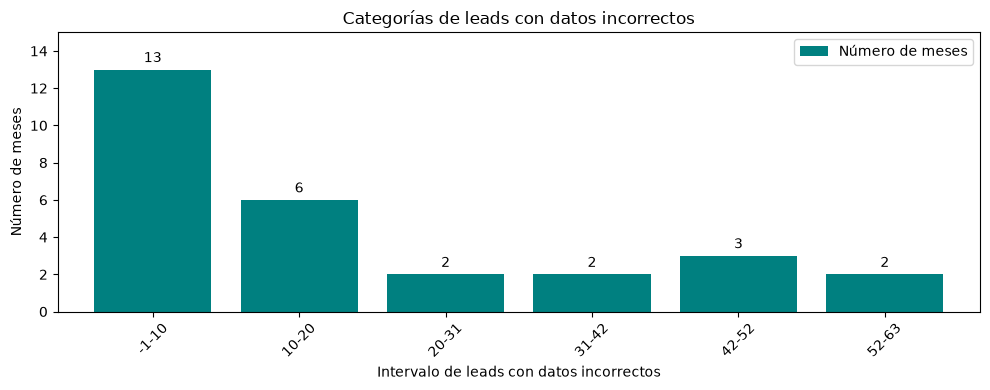

In [98]:
# Gráfica de barras 5: D. Incorrectos

ax =Filtro_Incorrectos_index.plot(kind="bar",width=0.8,figsize=(10, 4),color="teal",rot=45)

ax.bar_label(ax.containers[0], padding=3)

plt.ylim(0, Filtro_Incorrectos_index["count"].max() + 2)

plt.title("Categorías de leads con datos incorrectos")
plt.xlabel("Intervalo de leads con datos incorrectos")
plt.ylabel("Número de meses")
plt.legend(["Número de meses"])
plt.tight_layout()
plt.show()

In [79]:
# Variable 6: Duplicados

# Limites, rango y amplitud de Duplicados

Max_Duplicados = Leads["Duplicados"].max()
Min_Duplicados = Leads["Duplicados"].min()

R_Duplicados = Max_Duplicados - Min_Duplicados
i_Duplicados = R_Duplicados / numero_intervalos

print("Límites:", [Min_Duplicados, Max_Duplicados])
print("Rango:", R_Duplicados)
print("Amplitud:", i_Duplicados)

Límites: [np.int64(0), np.int64(136)]
Rango: 136
Amplitud: 22.666666666666668


In [80]:
# Intervalos para Duplicados

intervalos_Duplicados = np.linspace(-1, 137, 7)

intervalos_Duplicados

array([ -1.,  22.,  45.,  68.,  91., 114., 137.])

In [81]:
# Nombres de las categorías

categorias_Duplicados = ["-1-22","22-45",
                         "45-68","68-91",
                         "91-114","114-137"]

In [82]:
# Categorizamos la variable Duplicados

Leads["Categoria Duplicados"] = pd.cut(x=Leads["Duplicados"],bins=intervalos_Duplicados,labels=categorias_Duplicados,include_lowest=True)

Leads[["Duplicados", "Categoria Duplicados"]]

,Duplicados,Categoria Duplicados
0,1,-1-22
1,0,-1-22
2,0,-1-22
3,0,-1-22
4,3,-1-22
5,9,-1-22
6,18,-1-22
7,26,22-45
8,13,-1-22
9,4,-1-22


In [83]:
# Tabla de frecuencias

Tabla_Duplicados = Leads["Categoria Duplicados"].value_counts(sort=False).reset_index()

Tabla_Duplicados

,Categoria Duplicados,count
0,-1-22,13
1,22-45,6
2,45-68,6
3,68-91,1
4,91-114,1
5,114-137,1


In [84]:
# Categorías con frecuencia mayor a cero

Filtro_Duplicados = Tabla_Duplicados[Tabla_Duplicados["count"] > 0]

Filtro_Duplicados

,Categoria Duplicados,count
0,-1-22,13
1,22-45,6
2,45-68,6
3,68-91,1
4,91-114,1
5,114-137,1


In [85]:
# Ajustamos el índice

Filtro_Duplicados_index = Filtro_Duplicados.set_index("Categoria Duplicados")

Filtro_Duplicados_index

,count
Categoria Duplicados,
-1-22,13
22-45,6
45-68,6
68-91,1
91-114,1
114-137,1


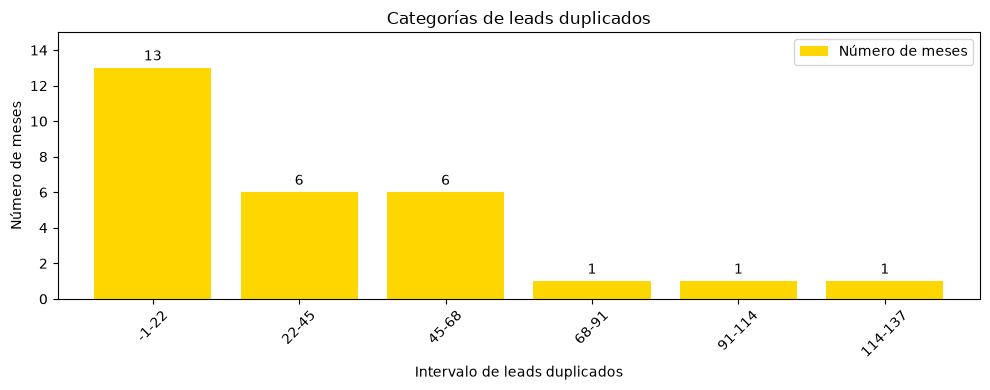

In [99]:
# Gráfica de barras 6: Duplicados

ax = Filtro_Duplicados_index.plot(kind="bar",width=0.8,figsize=(10, 4),color="gold",rot=45)

ax.bar_label(ax.containers[0], padding=3)

plt.ylim(0, Filtro_Duplicados_index["count"].max() + 2)

plt.title("Categorías de leads duplicados")
plt.xlabel("Intervalo de leads duplicados")
plt.ylabel("Número de meses")
plt.legend(["Número de meses"])
plt.tight_layout()
plt.show()

In [87]:
# Variable 7: Abiertos

# Límites, rango y amplitud de Abiertos

Max_Abiertos = Leads["Abiertos"].max()
Min_Abiertos = Leads["Abiertos"].min()

R_Abiertos = Max_Abiertos - Min_Abiertos
i_Abiertos = R_Abiertos / numero_intervalos

print("Límites:", [Min_Abiertos, Max_Abiertos])
print("Rango:", R_Abiertos)
print("Amplitud:", i_Abiertos)

Límites: [np.int64(1), np.int64(823)]
Rango: 822
Amplitud: 137.0


In [88]:
# Intervalos para Abiertos

intervalos_Abiertos = np.linspace(0, 824, 7)

intervalos_Abiertos

array([  0.        , 137.33333333, 274.66666667, 412.        ,
       549.33333333, 686.66666667, 824.        ])

In [89]:
# Nombres de las categorías

categorias_Abiertos = ["0-137","137-275",
                       "275-412","412-549",
                       "549-687","687-824"]

In [90]:
# Categorizamos la variable Abiertos

Leads["Categoria Abiertos"] = pd.cut(x=Leads["Abiertos"],bins=intervalos_Abiertos,labels=categorias_Abiertos,include_lowest=True)

Leads[["Abiertos", "Categoria Abiertos"]]

,Abiertos,Categoria Abiertos
0,1,0-137
1,1,0-137
2,1,0-137
3,5,0-137
4,17,0-137
5,5,0-137
6,22,0-137
7,42,0-137
8,72,0-137
9,79,0-137


In [91]:
# Tabla de frecuencias

Tabla_Abiertos = Leads["Categoria Abiertos"].value_counts(sort=False).reset_index()

Tabla_Abiertos

,Categoria Abiertos,count
0,0-137,11
1,137-275,5
2,275-412,5
3,412-549,3
4,549-687,2
5,687-824,2


In [92]:
# Categorías con frecuencia mayor a cero

Filtro_Abiertos = Tabla_Abiertos[Tabla_Abiertos["count"] > 0]

Filtro_Abiertos

,Categoria Abiertos,count
0,0-137,11
1,137-275,5
2,275-412,5
3,412-549,3
4,549-687,2
5,687-824,2


In [93]:
# Ajustamos el índice

Filtro_Abiertos_index = Filtro_Abiertos.set_index("Categoria Abiertos")

Filtro_Abiertos_index

,count
Categoria Abiertos,
0-137,11
137-275,5
275-412,5
412-549,3
549-687,2
687-824,2


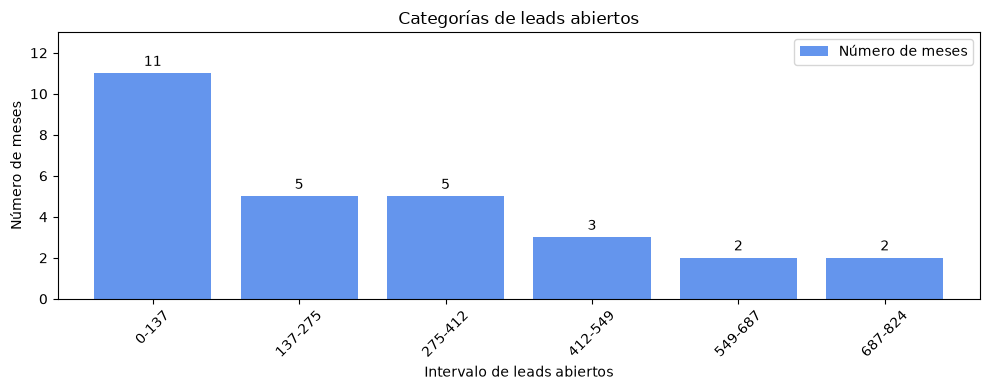

In [100]:
# Gráfica de barras 7: Abiertos

ax = Filtro_Abiertos_index.plot(kind="bar",width=0.8,figsize=(10, 4),color="cornflowerblue",rot=45)

ax.bar_label(ax.containers[0], padding=3)

plt.ylim(0, Filtro_Abiertos_index["count"].max() + 2)

plt.title("Categorías de leads abiertos")
plt.xlabel("Intervalo de leads abiertos")
plt.ylabel("Número de meses")
plt.legend(["Número de meses"])
plt.tight_layout()
plt.show()